# Goals:
Predict Total Wait Time (min) for patients AND identify factors that influence long wait times to optimize hospital workflows.

Note: Normalize the data to Ontario numbers to make it more predictable

# Approach Breakdown

Step 1: Data Loading
- Read in dataset
- Import packages

Step 2: Exploratory Data Analysis
- Identify null values
- what numeric factors lead to high waiting times

Step 3: Data Preprocessing
- Handle missing values (mean/median for numeric, mode or “Unknown” for categorical)
- Convert dates to features: e.g., Visit Date → Day of Week, Hour, Month, Season
- Encode categorical variables: One-Hot Encoding or Target Encoding

Step 4: Model Building (all tentative as of now)
- Linear Regression / Polynomial Regression
- Ridge Regression & Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- Neural Networks

Step 5: Model Evaluation (Use MAE, RMSE, MAPE (for interpretability?, Create confidence intervals?)

Step 6: Conclusion

# Step 1: Data Loading

In [15]:
# Load the dataset
# Import packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('ER_Wait_Time_Dataset.csv')

In [11]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64


In [ ]:
# Display basic information
print("Dataset shape:", df.shape)

print("\nFirst few rows:")
print(df.head())

Dataset shape: (5000, 19)

First few rows:
               Visit ID Patient ID Hospital ID                 Hospital Name  \
0  HOSP-1-20240210-0001  PAT-00001      HOSP-1  Springfield General Hospital   
1  HOSP-3-20241128-0001  PAT-00002      HOSP-3  Northside Community Hospital   
2  HOSP-3-20240930-0002  PAT-00003      HOSP-3  Northside Community Hospital   
3  HOSP-2-20240227-0001  PAT-00004      HOSP-2      Riverside Medical Center   
4  HOSP-1-20240306-0002  PAT-00005      HOSP-1  Springfield General Hospital   

  Region           Visit Date Day of Week  Season   Time of Day Urgency Level  \
0  Urban  2024-02-10 20:20:56    Saturday  Winter  Late Morning        Medium   
1  Rural  2024-11-28 02:07:47    Thursday    Fall       Evening        Medium   
2  Rural  2024-09-30 04:02:28      Monday    Fall       Evening           Low   
3  Urban  2024-02-27 00:31:13     Tuesday  Winter       Evening          High   
4  Urban  2024-03-06 16:52:26   Wednesday  Spring     Afternoon        

In [10]:
print("\nColumn names:")
print(df.columns.tolist())

print("\nBasic statistics:")
print(df.describe())


Column names:
['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region', 'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Time to Registration (min)', 'Time to Triage (min)', 'Time to Medical Professional (min)', 'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction']

Basic statistics:
       Nurse-to-Patient Ratio  Specialist Availability  Facility Size (Beds)  \
count             5000.000000              5000.000000           5000.000000   
mean                 3.238200                 3.875000             87.118800   
std                  1.200895                 3.043292             57.998585   
min                  1.000000                 0.000000             10.000000   
25%                  3.000000                 1.000000             36.000000   
50%                  3.000000                 3.000000             74.000000   
75%                  4.000000

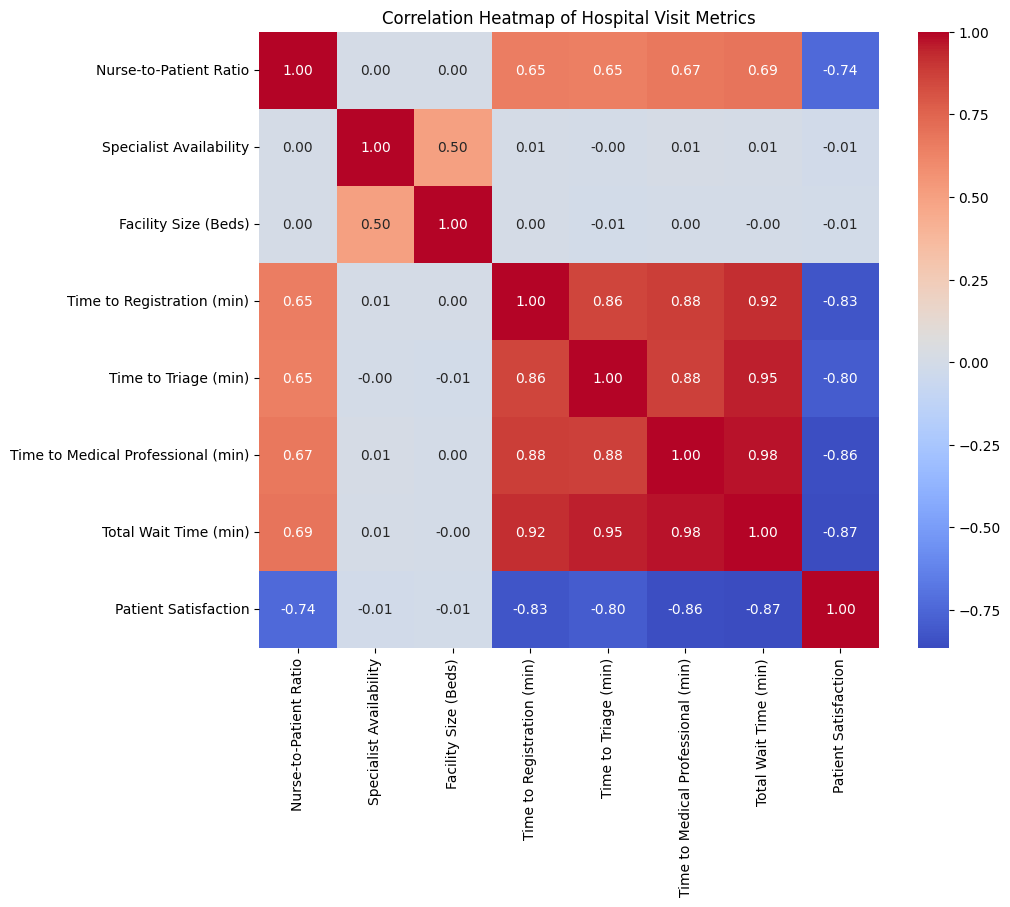

In [16]:
# Assume your data is loaded in a DataFrame called df
numeric_cols = [
    'Nurse-to-Patient Ratio', 
    'Specialist Availability', 
    'Facility Size (Beds)',
    'Time to Registration (min)', 
    'Time to Triage (min)', 
    'Time to Medical Professional (min)', 
    'Total Wait Time (min)', 
    'Patient Satisfaction'
]

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Hospital Visit Metrics")
plt.show()

In [6]:
print("\nTarget variable stats:")
print(df['Total Wait Time (min)'].describe())


Target variable stats:
count    5000.000000
mean       81.916600
std        68.084538
min         4.000000
25%        27.000000
50%        60.000000
75%       122.000000
max       442.000000
Name: Total Wait Time (min), dtype: float64


## Feature Engineering & Encoding

In [7]:
# Encode ordinal features
urgency_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['Urgency Encoded'] = df['Urgency Level'].map(urgency_map)

time_map = {'Morning': 1, 'Late Morning': 2, 'Afternoon': 3, 'Evening': 4, 'Night': 5}
df['Time Encoded'] = df['Time of Day'].map(time_map)

season_map = {'Spring': 1, 'Summer': 2, 'Fall': 3, 'Winter': 4}
df['Season Encoded'] = df['Season'].map(season_map)

# Encode categorical features
df['Region Encoded'] = LabelEncoder().fit_transform(df['Region'])
df['Is Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)

# Select features for the model
features = [
    'Urgency Encoded',
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Time Encoded',
    'Season Encoded',
    'Region Encoded',
    'Is Weekend',
]

X = df[features]
y = df['Total Wait Time (min)']

print("Features shape:", X.shape)
print(X.head())

Features shape: (5000, 8)
   Urgency Encoded  Nurse-to-Patient Ratio  Specialist Availability  \
0                2                       4                        3   
1                2                       4                        0   
2                1                       5                        1   
3                3                       4                        5   
4                1                       4                        8   

   Facility Size (Beds)  Time Encoded  Season Encoded  Region Encoded  \
0                    92           2.0               4               1   
1                    38           4.0               3               0   
2                    38           4.0               3               0   
3                    94           4.0               4               1   
4                    74           3.0               1               1   

   Is Weekend  
0           1  
1           0  
2           0  
3           0  
4           0  


## Linear Regression Model

In [8]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} minutes")
print(f"R² Score: {r2:.4f}")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Feature coefficients — which factors drive wait time?
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Coefficients (impact on Total Wait Time):")
print(coef_df.to_string(index=False))

NameError: name 'pd' is not defined